# WattwAIs Deep Learning Regression Models

This notebook trains deep learning models to predict hourly household electricity demand.

Target variable:

`Demand_kWh`

The dataset is treated as tabular regression data, not pure sequential time-series data.

Models used:
- MLP
- Residual MLP
- Wide & Deep Neural Network
- 1D CNN
- GRU

The final output includes:
- Model name
- MAE
- RMSE
- R²
- MAPE
- Actual vs predicted sample
- Best model saved as `.keras`

## 1. Upload Cleaned Dataset

Upload the cleaned WattwAIs dataset CSV file.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving wattwais_iflex_cleaned_dataset.csv to wattwais_iflex_cleaned_dataset.csv


## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import shutil
import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Add,
    Concatenate,
    Conv1D,
    Flatten,
    GRU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("tensorflow version:", tf.__version__)

tensorflow version: 2.20.0


## 3. Load Dataset

In [3]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("loaded file:", filename)
print("dataset shape:", df.shape)

df.head()

loaded file: wattwais_iflex_cleaned_dataset.csv
dataset shape: (170088, 24)


,ID,From,Date,Demand_kWh,hour,day_of_week,month,day,is_weekend,Experiment_price_NOK_kWh,...,lag_1,lag_24,lag_168,rolling_24,rolling_168,Region,Municipality,Participation_Phase,Control_Price_Phase2,Group_Phase2
0,Exp_135,2020-02-11 00:00:00+00:00,11/02/2020,0.408,0,1,2,11,0,1.0,...,0.489,0.483,0.961,3.417042,3.347833,Bergen,Bergen,Phase_1,Price group,H1
1,Exp_35,2020-02-11 00:00:00+00:00,11/02/2020,1.731,0,1,2,11,0,1.0,...,3.459,1.403,1.737,2.888042,3.030720,Bergen,Bergen,Phase_1,Price group,H1
2,Exp_159,2020-02-11 00:00:00+00:00,11/02/2020,1.127,0,1,2,11,0,1.0,...,0.580,0.395,0.745,0.515667,0.538518,Oslo,Oslo,Phase_1,Price group,H1
3,Exp_191,2020-02-11 00:00:00+00:00,11/02/2020,0.793,0,1,2,11,0,1.0,...,1.194,0.722,0.803,2.341667,2.632506,Oslo,Oslo,Phase_1,Unknown,Unknown
4,Exp_44,2020-02-11 00:00:00+00:00,11/02/2020,1.064,0,1,2,11,0,1.0,...,1.135,1.223,3.892,4.391667,4.303310,Oslo,Bærum,Phase_1,Price group,H1


## 4. Inspect Dataset

In [4]:
print("columns:")
print(df.columns.tolist())

print("\ndataset info:")
df.info()

df.describe(include="all").T

columns:
['ID', 'From', 'Date', 'Demand_kWh', 'hour', 'day_of_week', 'month', 'day', 'is_weekend', 'Experiment_price_NOK_kWh', 'Temperature', 'Temperature24', 'Temperature48', 'Temperature72', 'lag_1', 'lag_24', 'lag_168', 'rolling_24', 'rolling_168', 'Region', 'Municipality', 'Participation_Phase', 'Control_Price_Phase2', 'Group_Phase2']

dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170088 entries, 0 to 170087
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        170088 non-null  object 
 1   From                      170088 non-null  object 
 2   Date                      170088 non-null  object 
 3   Demand_kWh                170088 non-null  float64
 4   hour                      170088 non-null  int64  
 5   day_of_week               170088 non-null  int64  
 6   month                     170088 non-null  int64  
 7   day                     

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,170088,350,Exp_135,624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
From,170088,1320,2021-01-18 15:00:00+00:00,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,170088,55,18/01/2021,7728,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Demand_kWh,170088.0,NaN,NaN,NaN,2.949261,2.216123,0.0,1.2,2.57,4.17,19.05
hour,170088.0,NaN,NaN,NaN,11.5,6.922207,0.0,5.75,11.5,17.25,23.0
day_of_week,170088.0,NaN,NaN,NaN,1.839001,1.407983,0.0,1.0,2.0,3.0,4.0
month,170088.0,NaN,NaN,NaN,2.567095,2.690312,1.0,1.0,2.0,3.0,12.0
day,170088.0,NaN,NaN,NaN,13.731903,7.726771,1.0,8.0,13.0,18.0,29.0
is_weekend,170088.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Experiment_price_NOK_kWh,170088.0,NaN,NaN,NaN,3.374264,4.260177,0.0,1.0,1.09,4.98,30.15


## 5. Basic Data Cleaning

The target variable is `Demand_kWh`, which represents hourly electricity demand.

In [5]:
target_col = "Demand_kWh"

df = df.copy()

if "From" in df.columns:
    df["From"] = pd.to_datetime(df["From"], errors="coerce")
    df = df.sort_values("From").reset_index(drop=True)

df = df.dropna(subset=[target_col])

print("cleaned dataset shape:", df.shape)
df.head()

cleaned dataset shape: (170088, 24)


,ID,From,Date,Demand_kWh,hour,day_of_week,month,day,is_weekend,Experiment_price_NOK_kWh,...,lag_1,lag_24,lag_168,rolling_24,rolling_168,Region,Municipality,Participation_Phase,Control_Price_Phase2,Group_Phase2
0,Exp_135,2020-02-11 00:00:00+00:00,11/02/2020,0.408,0,1,2,11,0,1.0,...,0.489,0.483,0.961,3.417042,3.347833,Bergen,Bergen,Phase_1,Price group,H1
1,Exp_61,2020-02-11 00:00:00+00:00,11/02/2020,0.430,0,1,2,11,0,1.0,...,0.958,0.412,0.258,1.180250,0.661226,Bergen,Bergen,Phase_1,Price group,H1
2,Exp_208,2020-02-11 00:00:00+00:00,11/02/2020,2.692,0,1,2,11,0,1.0,...,3.506,3.330,1.997,3.566792,3.784619,Oslo,Oslo,Phase_1,Unknown,Unknown
3,Exp_62,2020-02-11 00:00:00+00:00,11/02/2020,1.538,0,1,2,11,0,1.0,...,3.077,1.681,1.915,2.402333,2.731500,Bergen,Bergen,Phase_1,Unknown,Unknown
4,Exp_75,2020-02-11 00:00:00+00:00,11/02/2020,5.690,0,1,2,11,0,1.0,...,6.199,3.443,4.888,4.689167,4.765708,Bergen,Bergen,Phase_1,Price group,H1


## 6. Define Features and Target

The model predicts `Demand_kWh` using available time, weather, pricing, household, and historical consumption features.

In [6]:
excluded_cols = [
    target_col,
    "From",
    "Date"
]

feature_cols = [col for col in df.columns if col not in excluded_cols]

numeric_features = df[feature_cols].select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = df[feature_cols].select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("target column:", target_col)
print("\nnumeric features:")
print(numeric_features)

print("\ncategorical features:")
print(categorical_features)

print("\nnumber of input features:", len(feature_cols))

target column: Demand_kWh

numeric features:
['hour', 'day_of_week', 'month', 'day', 'is_weekend', 'Experiment_price_NOK_kWh', 'Temperature', 'Temperature24', 'Temperature48', 'Temperature72', 'lag_1', 'lag_24', 'lag_168', 'rolling_24', 'rolling_168']

categorical features:
['ID', 'Region', 'Municipality', 'Participation_Phase', 'Control_Price_Phase2', 'Group_Phase2']

number of input features: 21


## 7. Handle Missing Values

In [7]:
df_model = df.copy()

for col in numeric_features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

for col in categorical_features:
    df_model[col] = df_model[col].fillna("Unknown").astype(str)

print("remaining missing values:")
print(df_model[feature_cols + [target_col]].isnull().sum().sort_values(ascending=False).head(20))

remaining missing values:
ID                          0
hour                        0
day_of_week                 0
month                       0
day                         0
is_weekend                  0
Experiment_price_NOK_kWh    0
Temperature                 0
Temperature24               0
Temperature48               0
Temperature72               0
lag_1                       0
lag_24                      0
lag_168                     0
rolling_24                  0
rolling_168                 0
Region                      0
Municipality                0
Participation_Phase         0
Control_Price_Phase2        0
dtype: int64


## 8. Train-Test Split

Since the data contains time-based electricity records, the split is done without shuffling.
The earlier 80% of the data is used for training, while the later 20% is used for testing.

In [8]:
if "From" in df_model.columns:
    df_model = df_model.sort_values("From").reset_index(drop=True)

split_index = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_index].copy()
test_df = df_model.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col].values

X_test = test_df[feature_cols]
y_test = test_df[target_col].values

print("training shape:", X_train.shape)
print("testing shape:", X_test.shape)

training shape: (136070, 21)
testing shape: (34018, 21)


## 9. Preprocess Features

Numeric features are standardized, while categorical features are one-hot encoded.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed = np.asarray(X_train_processed).astype("float32")
X_test_processed = np.asarray(X_test_processed).astype("float32")

y_train = np.asarray(y_train).astype("float32")
y_test = np.asarray(y_test).astype("float32")

input_dim = X_train_processed.shape[1]

print("processed training shape:", X_train_processed.shape)
print("processed testing shape:", X_test_processed.shape)
print("input dimension:", input_dim)

processed training shape: (136070, 399)
processed testing shape: (34018, 399)
input dimension: 399


## 10. Evaluation Functions

In [10]:
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_model(model_name, model, X_eval, y_true):
    y_pred = model.predict(X_eval, verbose=0).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = safe_mape(y_true, y_pred)

    result = {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

    return result, y_pred

## 11. Training Callback

Early stopping prevents overfitting by stopping training when validation loss no longer improves.

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

## 12. MLP Model

In [12]:
def build_mlp(input_dim):
    inputs = Input(shape=(input_dim,))

    x = Dense(128, activation="relu")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Dense(32, activation="relu")(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


mlp_model = build_mlp(input_dim)
mlp_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 399)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        51,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,337 (243.50 KB)

 Trainable params: 61,953 (242.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [13]:
mlp_history = mlp_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 1.1644 - mae: 0.7523 - val_loss: 0.6864 - val_mae: 0.5618
Epoch 2/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8039 - mae: 0.6213 - val_loss: 0.6151 - val_mae: 0.5349
Epoch 3/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7633 - mae: 0.6001 - val_loss: 0.6153 - val_mae: 0.5363
Epoch 4/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7417 - mae: 0.5877 - val_loss: 0.6046 - val_mae: 0.5181
Epoch 5/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7231 - mae: 0.5781 - val_loss: 0.5914 - val_mae: 0.5196
Epoch 6/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7082 - mae: 0.5702 - val_loss: 0.5882 - val_mae: 0.5163
Epoch 7/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6914 - mae: 0.5653 - val_loss: 0.6127 - val_mae: 0.5224
Epoch 8/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6857 - mae: 0.5610 - val_loss: 0.6437 - val_mae: 0.5264
Epoch 9/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

## 13. Residual MLP Model

In [14]:
def residual_block(x, units):
    shortcut = Dense(units)(x)

    x = Dense(units, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Dense(units)(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation("relu")(x)

    return x


def build_residual_mlp(input_dim):
    inputs = Input(shape=(input_dim,))

    x = Dense(128, activation="relu")(inputs)
    x = residual_block(x, 128)
    x = residual_block(x, 64)

    x = Dense(32, activation="relu")(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


residual_mlp_model = build_residual_mlp(input_dim)
residual_mlp_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 399)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     51,200 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     16,512 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     16,512 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      4,160 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      8,256 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64)        │          0 │ batch_normalizat… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64)        │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │      2,080 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │         33 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 125,057 (488.50 KB)

 Trainable params: 124,289 (485.50 KB)

 Non-trainable params: 768 (3.00 KB)

In [15]:
residual_mlp_history = residual_mlp_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.9247 - mae: 0.6512 - val_loss: 0.8413 - val_mae: 0.6141
Epoch 2/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6727 - mae: 0.5578 - val_loss: 0.6159 - val_mae: 0.5237
Epoch 3/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6340 - mae: 0.5374 - val_loss: 0.5973 - val_mae: 0.5190
Epoch 4/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6222 - mae: 0.5300 - val_loss: 0.5933 - val_mae: 0.5140
Epoch 5/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6051 - mae: 0.5208 - val_loss: 0.5941 - val_mae: 0.5208
Epoch 6/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5945 - mae: 0.5163 - val_loss: 0.5753 - val_mae: 0.5074
Epoch 7/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5843 - mae: 0.5104 - val_loss: 0.5855 - val_mae: 0.5213
Epoch 8/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5766 - mae: 0.5067 - val_loss: 0.5943 - val_mae: 0.5247
Epoch 9/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4m

## 14. Wide & Deep Model

In [16]:
def build_wide_deep(input_dim):
    inputs = Input(shape=(input_dim,))

    wide = Dense(64, activation="linear")(inputs)

    deep = Dense(128, activation="relu")(inputs)
    deep = BatchNormalization()(deep)
    deep = Dropout(0.2)(deep)

    deep = Dense(64, activation="relu")(deep)
    deep = BatchNormalization()(deep)
    deep = Dropout(0.2)(deep)

    deep = Dense(32, activation="relu")(deep)

    combined = Concatenate()([wide, deep])

    x = Dense(64, activation="relu")(combined)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


wide_deep_model = build_wide_deep(input_dim)
wide_deep_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 399)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     51,200 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │     25,600 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 32)        │      2,080 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense_13[0][0],   │
│ (Concatenate)       │                   │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 1)         │         65 │ dense_17[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 94,177 (367.88 KB)

 Trainable params: 93,793 (366.38 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
wide_deep_history = wide_deep_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.9778 - mae: 0.6392 - val_loss: 0.6144 - val_mae: 0.5231
Epoch 2/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6424 - mae: 0.5387 - val_loss: 0.5967 - val_mae: 0.5251
Epoch 3/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6331 - mae: 0.5336 - val_loss: 0.5950 - val_mae: 0.5247
Epoch 4/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6216 - mae: 0.5275 - val_loss: 0.5860 - val_mae: 0.5162
Epoch 5/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6146 - mae: 0.5248 - val_loss: 0.5846 - val_mae: 0.5243
Epoch 6/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6064 - mae: 0.5208 - val_loss: 0.5922 - val_mae: 0.5132
Epoch 7/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5970 - mae: 0.5166 - val_loss: 0.5699 - val_mae: 0.5084
Epoch 8/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5916 - mae: 0.5133 - val_loss: 0.5726 - val_mae: 0.5118
Epoch 9/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms

## 15. Prepare Reshaped Input for 1D CNN and GRU

The 1D CNN and GRU models require 3D input.

Since this dataset is tabular, the processed feature vector is reshaped into a feature sequence representation.

In [18]:
X_train_seq = X_train_processed.reshape(
    X_train_processed.shape[0],
    X_train_processed.shape[1],
    1
)

X_test_seq = X_test_processed.reshape(
    X_test_processed.shape[0],
    X_test_processed.shape[1],
    1
)

print("sequential training shape:", X_train_seq.shape)
print("sequential testing shape:", X_test_seq.shape)

sequential training shape: (136070, 399, 1)
sequential testing shape: (34018, 399, 1)


## 16. 1D CNN Model

In [19]:
def build_1d_cnn(input_dim):
    inputs = Input(shape=(input_dim, 1))

    x = Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inputs)
    x = BatchNormalization()(x)

    x = Conv1D(filters=32, kernel_size=3, activation="relu", padding="same")(x)
    x = BatchNormalization()(x)

    x = Flatten()(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


cnn_model = build_1d_cnn(input_dim)
cnn_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 399, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 399, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 399, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 399, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 399, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │       817,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,097 (3.14 MB)

 Trainable params: 823,905 (3.14 MB)

 Non-trainable params: 192 (768.00 B)

In [20]:
cnn_history = cnn_model.fit(
    X_train_seq,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - loss: 2.6282 - mae: 0.9819 - val_loss: 13.4098 - val_mae: 2.9838
Epoch 2/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1.2060 - mae: 0.7425 - val_loss: 1.8801 - val_mae: 1.0996
Epoch 3/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1.1224 - mae: 0.7165 - val_loss: 0.6300 - val_mae: 0.5415
Epoch 4/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1.0677 - mae: 0.6969 - val_loss: 1.5628 - val_mae: 0.9622
Epoch 5/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1.0239 - mae: 0.6871 - val_loss: 0.7080 - val_mae: 0.5672
Epoch 6/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.9841 - mae: 0.6717 - val_loss: 0.6779 - val_mae: 0.5583
Epoch 7/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.9692 - mae: 0.6727 - val_loss: 0.6523 - val_mae: 0.5549
Epoch 8/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.9614 - mae: 0.6741 - val_loss: 0.6178 - val_mae: 0.5660
Epoch 9/100
426/426 ━━━━━━━━━━━━━━━━━━

## 17. GRU Model

In [21]:
def build_gru(input_dim):
    inputs = Input(shape=(input_dim, 1))

    x = GRU(64, return_sequences=False)(inputs)
    x = Dropout(0.2)(x)

    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)

    x = Dense(32, activation="relu")(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


gru_model = build_gru(input_dim)
gru_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 399, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,393 (75.75 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 128 (512.00 B)

In [22]:
gru_history = gru_model.fit(
    X_train_seq,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 5.6639 - mae: 1.8560 - val_loss: 7.3025 - val_mae: 1.9818
Epoch 2/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 5.2769 - mae: 1.8101 - val_loss: 5.1263 - val_mae: 1.7545
Epoch 3/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 5.2616 - mae: 1.8073 - val_loss: 5.1150 - val_mae: 1.7635
Epoch 4/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 5.1717 - mae: 1.7880 - val_loss: 4.9086 - val_mae: 1.7188
Epoch 5/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 5.0197 - mae: 1.7525 - val_loss: 4.9935 - val_mae: 1.7752
Epoch 6/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 4.9811 - mae: 1.7449 - val_loss: 4.9107 - val_mae: 1.6988
Epoch 7/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 4.9436 - mae: 1.7376 - val_loss: 4.9390 - val_mae: 1.6951
Epoch 8/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 4.9062 - mae: 1.7273 - val_loss: 4.8565 - val_mae: 1.6947
Epoch 9/100
426/426 ━━━━━━━━━━━━━

## 18. Evaluate All Models

In [23]:
models = {
    "MLP": (mlp_model, X_test_processed),
    "Residual MLP": (residual_mlp_model, X_test_processed),
    "Wide & Deep": (wide_deep_model, X_test_processed),
    "1D CNN": (cnn_model, X_test_seq),
    "GRU": (gru_model, X_test_seq)
}

results = []
predictions = {}

for model_name, (model, X_eval) in models.items():
    print("evaluating:", model_name)

    result, y_pred = evaluate_model(model_name, model, X_eval, y_test)

    results.append(result)
    predictions[model_name] = y_pred

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

results_df

evaluating: MLP
evaluating: Residual MLP
evaluating: Wide & Deep
evaluating: 1D CNN
evaluating: GRU


,Model,MAE,RMSE,R2,MAPE
0,MLP,0.497242,0.747572,0.829125,36.567142
1,Wide & Deep,0.517240,0.770918,0.818286,38.609013
2,Residual MLP,0.592691,0.890428,0.757578,37.099247
3,GRU,1.447272,1.971996,-0.189010,176.315933
4,1D CNN,2.303387,2.873763,-1.525081,92.660896


## 19. Actual vs Predicted Sample

In [24]:
best_model_name = results_df.iloc[0]["Model"]
best_predictions = predictions[best_model_name]

comparison_df = pd.DataFrame({
    "Actual Demand_kWh": y_test,
    "Predicted Demand_kWh": best_predictions
})

print("best model:", best_model_name)

comparison_df.head(20)

best model: MLP


,Actual Demand_kWh,Predicted Demand_kWh
0,2.100,1.784333
1,0.480,0.526107
2,0.140,0.243770
3,2.980,2.721889
4,0.440,0.504156
5,2.980,3.018043
6,2.370,1.488758
7,1.990,1.887162
8,2.101,2.549887
9,0.700,0.856957


## 20. Actual vs Predicted Visualization

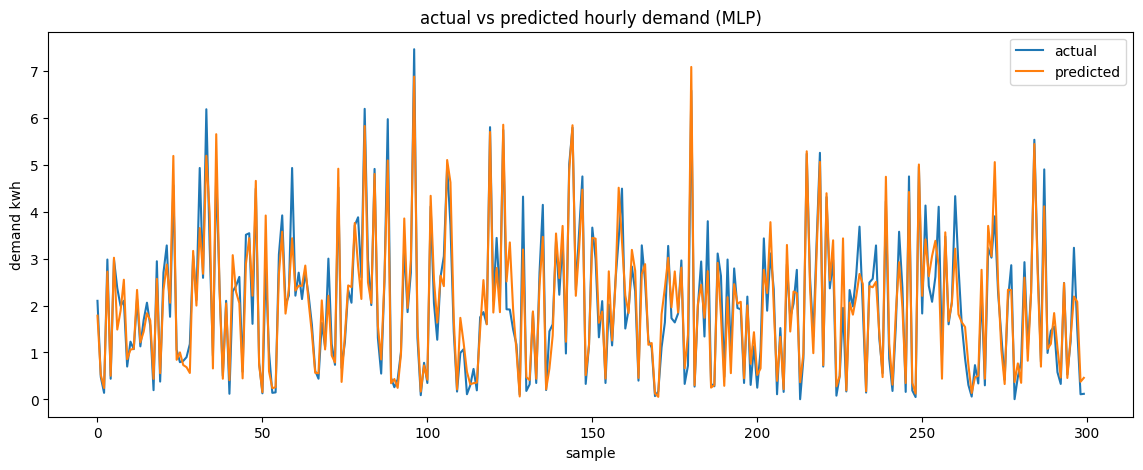

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(
    comparison_df["Actual Demand_kWh"].iloc[:300].values,
    label="actual"
)

plt.plot(
    comparison_df["Predicted Demand_kWh"].iloc[:300].values,
    label="predicted"
)

plt.xlabel("sample")
plt.ylabel("demand kwh")
plt.title(f"actual vs predicted hourly demand ({best_model_name})")
plt.legend()
plt.show()

## 21. Model Comparison Visualization

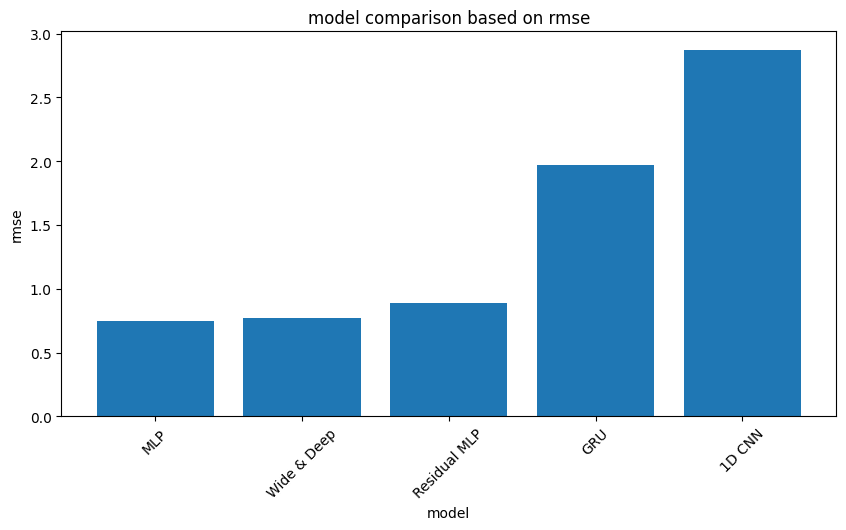

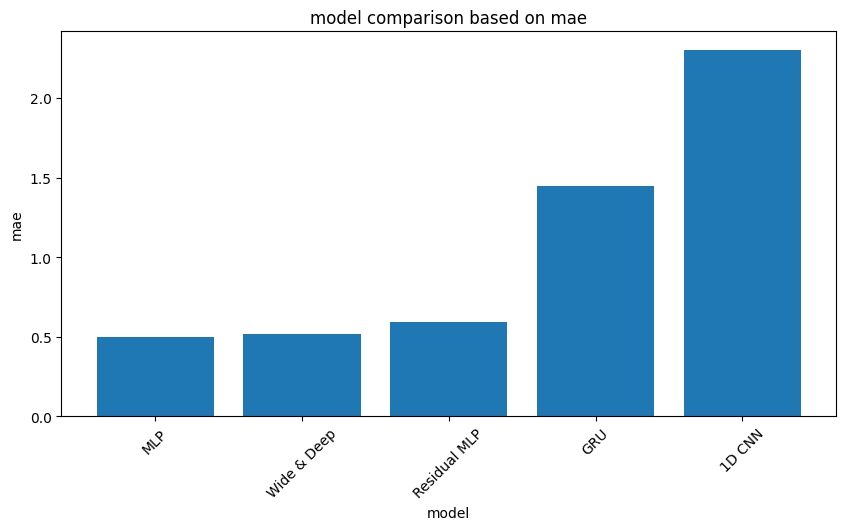

In [26]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xlabel("model")
plt.ylabel("rmse")
plt.title("model comparison based on rmse")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.xlabel("model")
plt.ylabel("mae")
plt.title("model comparison based on mae")
plt.xticks(rotation=45)
plt.show()

## 22. Save Best Model

In [27]:
os.makedirs("react_artifacts", exist_ok=True)

best_model = models[best_model_name][0]

keras_model_path = "react_artifacts/best_wattwais_model.keras"

best_model.save(keras_model_path)

print("best model:", best_model_name)
print("saved keras model:", keras_model_path)

best model: MLP
saved keras model: react_artifacts/best_wattwais_model.keras


save preprocessing files

In [28]:
os.makedirs("react_artifacts/preprocessing", exist_ok=True)

joblib.dump(preprocessor, "react_artifacts/preprocessing/preprocessor.pkl")

scaler = preprocessor.named_transformers_["num"]

scaler_data = {
    "numeric_features": numeric_features,
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist()
}

with open("react_artifacts/preprocessing/scaler.json", "w") as f:
    json.dump(scaler_data, f, indent=2)


encoder = preprocessor.named_transformers_["cat"]

categories_data = {
    "categorical_features": categorical_features,
    "categories": {
        col: encoder.categories_[i].tolist()
        for i, col in enumerate(categorical_features)
    }
}

with open("react_artifacts/preprocessing/categories.json", "w") as f:
    json.dump(categories_data, f, indent=2)


encoded_feature_names = encoder.get_feature_names_out(categorical_features).tolist()

feature_order = numeric_features + encoded_feature_names

with open("react_artifacts/preprocessing/feature_order.json", "w") as f:
    json.dump({"feature_order": feature_order}, f, indent=2)


input_template = {}

for col in numeric_features:
    input_template[col] = 0

for col in categorical_features:
    input_template[col] = categories_data["categories"][col][0]

with open("react_artifacts/preprocessing/input_template.json", "w") as f:
    json.dump(input_template, f, indent=2)


print("saved preprocessing files:")
print(os.listdir("react_artifacts/preprocessing"))

saved preprocessing files:
['categories.json', 'input_template.json', 'preprocessor.pkl', 'scaler.json', 'feature_order.json']


save csv files

In [29]:
os.makedirs("react_artifacts/data", exist_ok=True)

results_df.to_csv("react_artifacts/data/model_results.csv", index=False)
comparison_df.head(100).to_csv("react_artifacts/data/actual_vs_predicted_sample.csv", index=False)

print("saved data files:")
print(os.listdir("react_artifacts/data"))

saved data files:
['actual_vs_predicted_sample.csv', 'model_results.csv']


In [31]:
zip_path = shutil.make_archive("wattwais_react_model_artifacts", "zip", "react_artifacts")

print("created:", zip_path)
files.download(zip_path)

created: /content/wattwais_react_model_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import joblib
from google.colab import files

# export fitted preprocessor
joblib.dump(preprocessor, "preprocessor.pkl")

# download file
files.download("preprocessor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
!zip -q preprocessor.zip preprocessor.pkl
from google.colab import files
files.download("preprocessor.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>